In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

df = pd.read_csv('../data/cars_cleaned.csv')

X = df.drop(columns=['Price', 'log_price'])
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = joblib.load('../src/preprocessor.pkl')

In [6]:
import mlflow
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

models = {
    'linear_regression': LinearRegression(),
    'lightgbm': LGBMRegressor(n_estimators=300, random_state=42)
}

results = {}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)
        preds_log = pipeline.predict(X_test)

        # Evaluate in real MAD, not log-space — this is what actually matters for the business problem
        preds_price = np.expm1(preds_log)
        y_test_price = np.expm1(y_test)

        rmse = root_mean_squared_error(y_test_price, preds_price)
        mae = mean_absolute_error(y_test_price, preds_price)
        r2 = r2_score(y_test_price, preds_price)

        mlflow.log_param('model_type', name)
        mlflow.log_metrics({'rmse_mad': rmse, 'mae_mad': mae, 'r2': r2})
        mlflow.sklearn.log_model(pipeline, name)

        results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'pipeline': pipeline}
        print(f"{name}: RMSE={rmse:.0f} MAD, MAE={mae:.0f} MAD, R²={r2:.3f}")

2026/06/17 05:39:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/17 05:39:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


linear_regression: RMSE=94160 MAD, MAE=39139 MAD, R²=0.489
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 608
[LightGBM] [Info] Number of data points in the train set: 60368, number of used features: 30
[LightGBM] [Info] Start training from score 11.556147


c:\Users\Dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
2026/06/17 05:39:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/17 05:39:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


lightgbm: RMSE=69246 MAD, MAE=22277 MAD, R²=0.724


In [7]:
best_pipeline = results['lightgbm']['pipeline']
joblib.dump(best_pipeline, '../src/model.pkl')

['../src/model.pkl']

In [8]:
import shap

# Extract just the LightGBM model from the pipeline (SHAP's TreeExplainer needs the raw model, not the full pipeline)
lgbm_model = best_pipeline.named_steps['model']

# Transform the test data through preprocessing first, since SHAP explains the model's view of the data, not raw input
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

In [10]:
numerical_features = ['Year', 'Number of Doors', 'Mileage_numeric', 'Fiscal_Power_numeric', 'car_age', 'mileage_per_year']

categorical_features = ['Brand', 'Condition', 'Gearbox', 'Fuel', 'Origin', 'First Owner', 'Location_grouped', 'Model_grouped']

binary_features = [c for c in X.columns if c.startswith('has_')]

feature_names = numerical_features + categorical_features + binary_features
print(len(feature_names), X_test_transformed.shape[1])

30 30


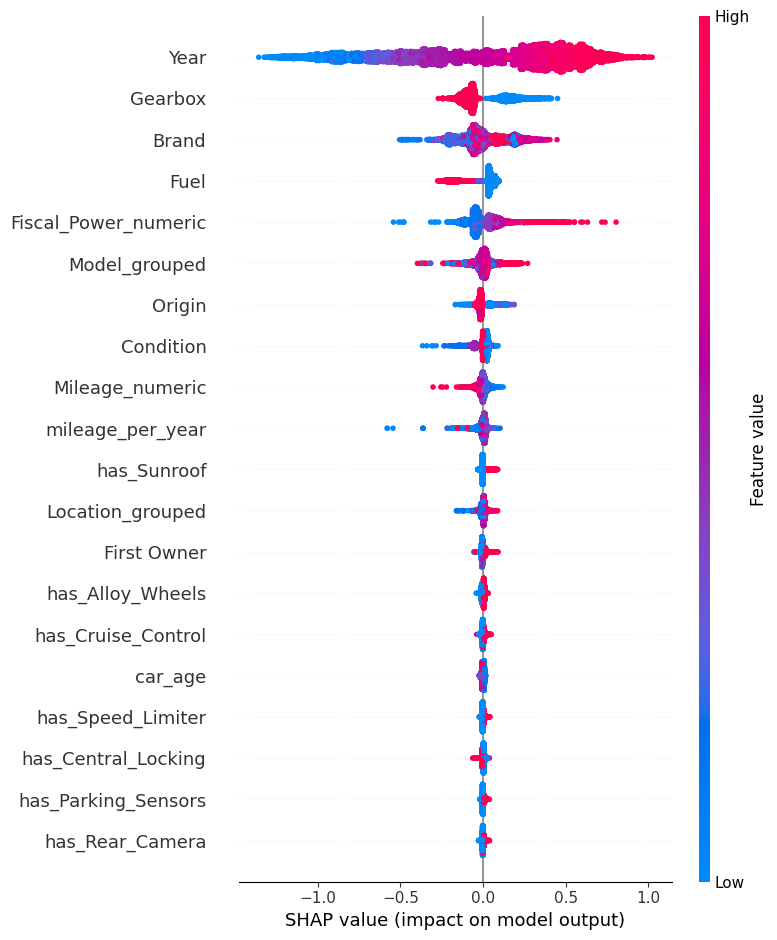

In [11]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=True)

In [14]:
def explain_single_prediction(input_df, pipeline, explainer, feature_names):
    transformed = pipeline.named_steps['preprocessor'].transform(input_df)
    shap_vals = explainer.shap_values(transformed)[0]
    return dict(zip(feature_names, shap_vals.tolist()))

# Test it on one row from your test set
sample = X_test.iloc[[0]]
explanation = explain_single_prediction(sample, best_pipeline, explainer, feature_names)

sorted_explanation = dict(sorted(explanation.items(), key=lambda x: abs(x[1]), reverse=True))
sorted_explanation

{'Year': 0.4912650107504842,
 'Gearbox': 0.2020831954774746,
 'Brand': 0.1729621621869671,
 'Origin': 0.1056894202822524,
 'Fiscal_Power_numeric': 0.09670134406144085,
 'Fuel': 0.03204374382018403,
 'has_Sunroof': 0.0252288689763569,
 'Condition': 0.021010224207314004,
 'Model_grouped': 0.017077792230605703,
 'has_Leather_Seats': 0.010685064360625674,
 'First Owner': 0.010421391597500055,
 'Mileage_numeric': 0.008470807766290778,
 'has_Navigation_System_GPS': 0.008058292471515856,
 'has_Speed_Limiter': -0.00706301577644148,
 'has_Cruise_Control': 0.006145741359568588,
 'Location_grouped': 0.005312244124243372,
 'has_Central_Locking': -0.004570938921825615,
 'has_Parking_Sensors': 0.004509364808637385,
 'mileage_per_year': 0.004255906315349313,
 'car_age': 0.003909201005335002,
 'has_Rear_Camera': 0.0037963246007537135,
 'has_Alloy_Wheels': 0.002763729952214684,
 'has_Airbags': 0.0018469723765424024,
 'Number of Doors': 0.001771279460613168,
 'has_CD_MP3_Bluetooth': -0.00166529514402330

In [15]:
joblib.dump(explainer, '../src/explainer.pkl')

with open('../src/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))